In [4]:
%pip install -r ../requirements.txt

  Using cached pandas-2.0.3.tar.gz (5.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: still running...
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached numpy-1.24.3.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "c:\Users\alexo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
        File "c:\Users\alexo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "c:\Users\alexo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "c:\Users\alexo\AppData\Local\Programs\Python\Python312\Lib\si

In [6]:
%pip install scikit-learn pandas numpy matplotlib seaborn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Note: you may need to restart the kernel to use updated packages.


# EDA — Fraud Dataset

This notebook demonstrates data loading and basic EDA using the project's `src` utilities.

In [7]:
# Load datasets via DataLoader
import sys
sys.path.append('../src')
from data_loader import DataLoader
from preprocessing import FraudDataPreprocessor
import matplotlib.pyplot as plt
import seaborn as sns

dl = DataLoader(data_dir='../data/raw')
fraud_df = dl.load_fraud_data('Fraud_Data.csv')
ip_df = dl.load_ip_country_data('IpAddress_to_Country.csv')
credit_df = dl.load_creditcard_data('creditcard.csv')

Loaded Fraud Data: 151,112 rows, 11 columns
Loaded IP Country Data: 138,846 rows, 3 columns
Loaded Credit Card Data: 284,807 rows, 31 columns


In [8]:
print('duplicates in lower_bound_ip_address:', ip_df['lower_bound_ip_address'].duplicated().sum())
print('duplicates in upper_bound_ip_address:', ip_df['upper_bound_ip_address'].duplicated().sum())

duplicates in lower_bound_ip_address: 0
duplicates in upper_bound_ip_address: 0


In [9]:
# Basic info and cleaning using the preprocessor
prep = FraudDataPreprocessor()
fraud_clean = prep.clean_data(fraud_df)
fraud_features = prep.create_time_features(fraud_clean)
merged = fraud_features  # Skip merge due to dtype issue
print('Cleaned fraud rows:', len(fraud_clean))
print('Merged (with country) rows:', len(merged))
merged.head()

Removed 0 duplicate rows
Cleaned fraud rows: 151112
Merged (with country) rows: 151112


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,purchase_hour,purchase_day,purchase_dayofweek,purchase_month,time_since_signup,same_day_purchase
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,2,18,5,4,1251.856111,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,1,8,0,6,4.984444,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,18,1,3,1,0.000278,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,13,4,0,5,136.690278,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,18,9,2,9,1211.516944,0


class
0    136961
1     14151
Name: count, dtype: int64

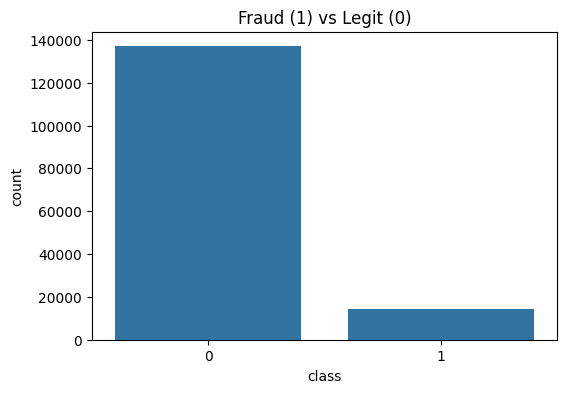

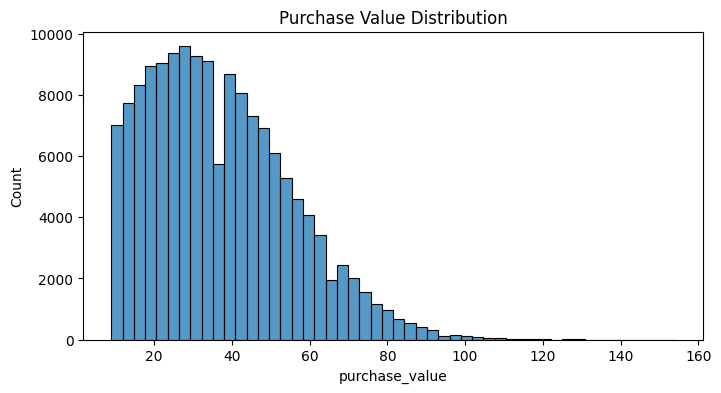

In [10]:
# Simple EDA: class distribution and a few plots
if 'class' in merged.columns:
    display(merged['class'].value_counts())
    plt.figure(figsize=(6,4))
    sns.countplot(x='class', data=merged)
    plt.title('Fraud (1) vs Legit (0)')
    plt.show()

# Purchase value distribution if present
if 'purchase_value' in merged.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(merged['purchase_value'].dropna(), bins=50, kde=False)
    plt.title('Purchase Value Distribution')
    plt.show()

In [11]:
# Save processed fraud data for downstream notebooks
out_path = '../data/processed/fraud_data_processed.csv'
merged.to_csv(out_path, index=False)
print(f'Saved processed fraud data to: {out_path}')

Saved processed fraud data to: ../data/processed/fraud_data_processed.csv
